In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)
import joblib

print("✅ All libraries imported successfully!")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")

✅ All libraries imported successfully!
   NumPy  : 2.3.5
   Pandas : 2.3.3


In [2]:
# ── 1.1  Array Basics ────────────────────────────────────────────────────────

# Create arrays in different ways
a = np.array([1, 2, 3, 4, 5])           # from list
b = np.arange(0, 10, 2)                  # [0, 2, 4, 6, 8]
c = np.linspace(0, 1, 6)                 # 6 evenly spaced between 0–1
zeros = np.zeros((3, 3))                 # 3x3 matrix of zeros
eye   = np.eye(3)                        # 3x3 identity matrix

print("a =", a)
print("b =", b)
print("c =", c)
print("zeros:\n", zeros)
print("identity:\n", eye)

a = [1 2 3 4 5]
b = [0 2 4 6 8]
c = [0.  0.2 0.4 0.6 0.8 1. ]
zeros:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
identity:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [3]:
# ── 1.2  Vectorised Operations ───────────────────────────────────────────────

x = np.arange(0, 10, 0.5)              # 20 values from 0 to 9.5
y_clean = np.sin(x)                    # sine wave — no loop!
noise   = np.random.normal(0, 0.1, x.shape)
y_noisy = y_clean + noise              # noisy sine

# ── 1.3  Z-Score Normalisation ───────────────────────────────────────────────
# Shifts mean to 0, scales std to 1
y_norm = (y_noisy - y_noisy.mean()) / y_noisy.std()

print(f"Original  → mean: {y_noisy.mean():.4f}, std: {y_noisy.std():.4f}")
print(f"Normalised → mean: {y_norm.mean():.4f}, std: {y_norm.std():.4f}")

Original  → mean: 0.2500, std: 0.6673
Normalised → mean: -0.0000, std: 1.0000


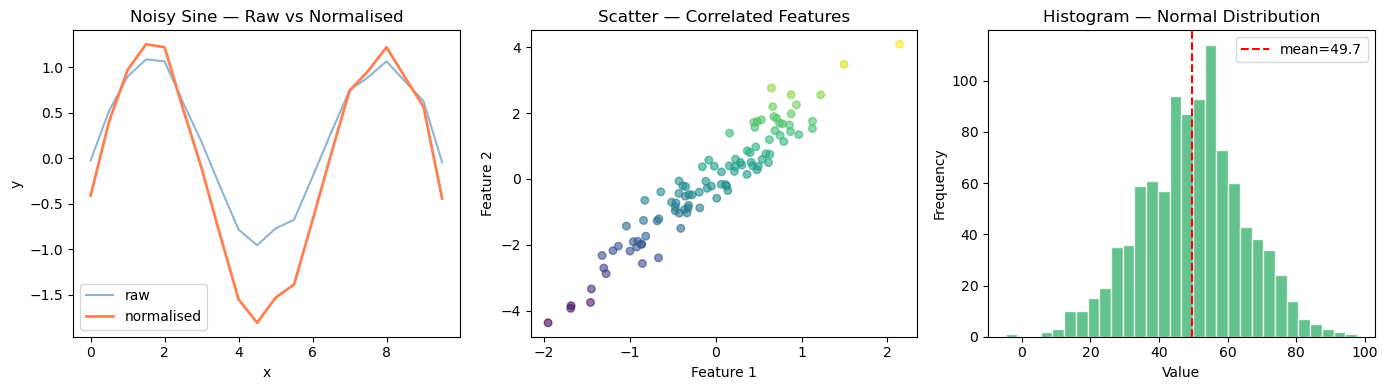

In [4]:
# ── 1.4  Matplotlib — Line + Histogram ───────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: raw vs normalised
axes[0].plot(x, y_noisy, label='raw', alpha=0.6, color='steelblue')
axes[0].plot(x, y_norm, label='normalised', color='coral', linewidth=2)
axes[0].set_title('Noisy Sine — Raw vs Normalised')
axes[0].legend()
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Plot 2: scatter of random 2D data
rng = np.random.default_rng(42)
sx = rng.normal(0, 1, 100)
sy = 2 * sx + rng.normal(0, 0.5, 100)
axes[1].scatter(sx, sy, alpha=0.6, c=sy, cmap='viridis', s=30)
axes[1].set_title('Scatter — Correlated Features')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')

# Plot 3: histogram
data = rng.normal(50, 15, 1000)
axes[2].hist(data, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.1f}')
axes[2].set_title('Histogram — Normal Distribution')
axes[2].set_xlabel('Value'); axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
# ── Quiz Q1: Axis operations ─────────────────────────────────────────────────
# Predict the output before running!

a = np.array([[1, 2, 3],
              [4, 5, 6]])

print("Sum axis=0 (column sums):", a.sum(axis=0))
print("Sum axis=1 (row sums)   :", a.sum(axis=1))
print("Shape:", a.shape)

Sum axis=0 (column sums): [5 7 9]
Sum axis=1 (row sums)   : [ 6 15]
Shape: (2, 3)


In [6]:
# ── Quiz Q2: Reshape & Flatten ───────────────────────────────────────────────

x = np.arange(12)
x2d  = x.reshape(3, 4)       # 3 rows, 4 cols
x3d  = x.reshape(2, 2, 3)    # 3D
flat = x2d.ravel()            # back to 1D

print("1D:", x)
print("2D (3x4):\n", x2d)
print("3D (2x2x3):\n", x3d)
print("Flattened:", flat)

1D: [ 0  1  2  3  4  5  6  7  8  9 10 11]
2D (3x4):
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
3D (2x2x3):
 [[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [7]:
# ── Quiz Q3: NaN Detection & Linear Algebra ──────────────────────────────────

v = np.array([3.0, 4.0, np.nan, 1.0])
print("Has NaN:", np.isnan(v).any())
print("NaN count:", np.isnan(v).sum())

# Euclidean norm (ignoring NaN)
v_clean = v[~np.isnan(v)]
print("L2 norm (clean):", np.linalg.norm(v_clean))

Has NaN: True
NaN count: 1
L2 norm (clean): 5.0990195135927845


In [8]:
# ── 3.1  Pandas Fundamentals ─────────────────────────────────────────────────

# Load Iris dataset directly into a DataFrame
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = iris.target_names[iris.target.values]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (150, 6)
Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [9]:
# ── 3.2  Exploratory Data Analysis ───────────────────────────────────────────

print("=== describe() — Statistical Summary ===")
print(df.describe().round(2))

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Distribution ===")
print(df['species'].value_counts())

=== describe() — Statistical Summary ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  target  
count            150.00  150.00  
mean               1.20    1.00  
std                0.76    0.82  
min                0.10    0.00  
25%                0.30    0.00  
50%                1.30    1.00  
75%                1.80    2.00  
max                2.50    2.00  

=== Missing Values ===
sepal length (cm)    0
sepal width (cm)    

In [10]:
# ── 3.3  GroupBy Analysis ────────────────────────────────────────────────────

print("Mean petal length per species:")
print(df.groupby('species')['petal length (cm)'].mean().round(3))

print("\nFull feature means per species:")
print(df.groupby('species')[iris.feature_names].mean().round(2))

Mean petal length per species:
species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64

Full feature means per species:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
species                       
setosa                  0.25  
versicolor              1.33  
virginica               2.03  


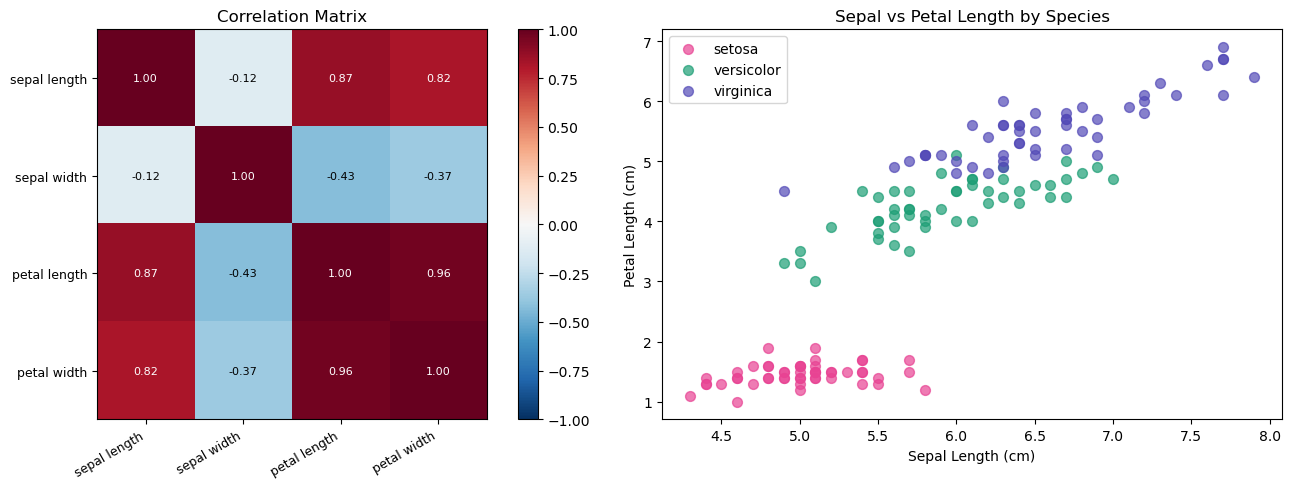

In [11]:
# ── 3.4  Correlation Matrix ───────────────────────────────────────────────────

numeric_cols = iris.feature_names
corr = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(numeric_cols)))
axes[0].set_yticks(range(len(numeric_cols)))
axes[0].set_xticklabels([c.replace(' (cm)','') for c in numeric_cols], rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels([c.replace(' (cm)','') for c in numeric_cols], fontsize=9)
axes[0].set_title('Correlation Matrix')
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        axes[0].text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center', fontsize=8,
                     color='white' if abs(corr.values[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=axes[0])

# Pair plot (sepal only for clarity)
colors = {'setosa':'#E84393', 'versicolor':'#1D9E75', 'virginica':'#534AB7'}
for species, grp in df.groupby('species'):
    axes[1].scatter(grp['sepal length (cm)'], grp['petal length (cm)'],
                    label=species, alpha=0.7, color=colors[species], s=50)
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Petal Length (cm)')
axes[1].set_title('Sepal vs Petal Length by Species')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# ── 3.5  Handling Missing Data ────────────────────────────────────────────────
# We simulate missing values to practise

df_dirty = df[numeric_cols].copy()
rng = np.random.default_rng(0)

# Inject 10 NaNs randomly
for _ in range(10):
    r, c = rng.integers(0, len(df_dirty)), rng.integers(0, len(numeric_cols))
    df_dirty.iloc[r, c] = np.nan

print("Missing values per column:")
print(df_dirty.isnull().sum())

# Strategy 1: Drop rows with any NaN
df_dropped = df_dirty.dropna()
print(f"\nAfter dropna: {len(df_dropped)} rows (lost {len(df_dirty)-len(df_dropped)})")

# Strategy 2: Fill with column mean (imputation)
df_filled = df_dirty.fillna(df_dirty.mean())
print(f"After mean imputation: {df_filled.isnull().sum().sum()} NaNs remaining")

Missing values per column:
sepal length (cm)    2
sepal width (cm)     1
petal length (cm)    4
petal width (cm)     3
dtype: int64

After dropna: 140 rows (lost 10)
After mean imputation: 0 NaNs remaining


In [13]:
# ── 3.6  Train / Test Split ───────────────────────────────────────────────────

X = df[numeric_cols]
y = iris.target

# stratify=y ensures each split has the same class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset size : {len(X)} samples")
print(f"Train set    : {len(X_train)} samples ({len(X_train)/len(X):.0%})")
print(f"Test set     : {len(X_test)} samples  ({len(X_test)/len(X):.0%})")

# Verify class balance
print("\nClass distribution in train:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class distribution in test :", dict(zip(*np.unique(y_test,  return_counts=True))))

Dataset size : 150 samples
Train set    : 120 samples (80%)
Test set     : 30 samples  (20%)

Class distribution in train: {np.int64(0): np.int64(40), np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Class distribution in test : {np.int64(0): np.int64(10), np.int64(1): np.int64(10), np.int64(2): np.int64(10)}


In [14]:
# ── 5.1  Feature Scaling ─────────────────────────────────────────────────────
# KNN is distance-based — features on different scales bias distances!

scaler = StandardScaler()                    # (x - mean) / std
X_train_sc = scaler.fit_transform(X_train)   # fit AND transform train
X_test_sc  = scaler.transform(X_test)        # ONLY transform test (no fit!)

print("Before scaling:")
print(f"  Train mean: {X_train.mean(axis=0).round(3).values}")
print(f"  Train std : {X_train.std(axis=0).round(3).values}")

print("\nAfter scaling:")
print(f"  Train mean: {X_train_sc.mean(axis=0).round(4)}")
print(f"  Train std : {X_train_sc.std(axis=0).round(4)}")

Before scaling:
  Train mean: [5.842 3.048 3.77  1.205]
  Train std : [0.841 0.449 1.769 0.763]

After scaling:
  Train mean: [-0.  0.  0.  0.]
  Train std : [1. 1. 1. 1.]


In [15]:
# ── 5.2  Train K-Nearest Neighbours ─────────────────────────────────────────

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

print("Model trained!")
print(f"  Algorithm : {knn.algorithm}")
print(f"  k         : {knn.n_neighbors}")
print(f"  Metric    : {knn.metric}")

Model trained!
  Algorithm : auto
  k         : 5
  Metric    : minkowski


In [16]:
# ── 5.2  Train K-Nearest Neighbours ─────────────────────────────────────────

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

print("Model trained!")
print(f"  Algorithm : {knn.algorithm}")
print(f"  k         : {knn.n_neighbors}")
print(f"  Metric    : {knn.metric}")

Model trained!
  Algorithm : auto
  k         : 5
  Metric    : minkowski


In [18]:
# ── 5.3  Evaluate ────────────────────────────────────────────────────────────

y_pred = knn.predict(X_test_sc)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



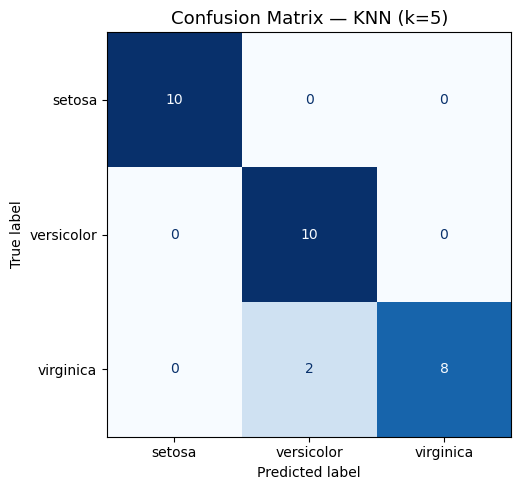


📖 How to read the confusion matrix:
  Diagonal   = correct predictions (TP for each class)
  Off-diagonal = misclassifications


In [19]:
# ── 5.4  Confusion Matrix ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    cmap='Blues',
    colorbar=False,
    ax=ax
)
ax.set_title('Confusion Matrix — KNN (k=5)', fontsize=13)
plt.tight_layout()
plt.show()

print("\n📖 How to read the confusion matrix:")
print("  Diagonal   = correct predictions (TP for each class)")
print("  Off-diagonal = misclassifications")

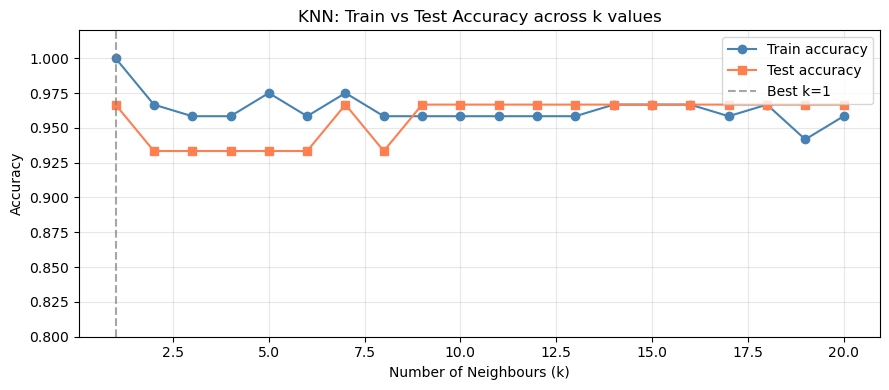


Best k = 1 with test accuracy = 96.67%


In [20]:
# ── 5.5  Hyperparameter Tuning — Finding Best k ───────────────────────────────

k_values = range(1, 21)
train_accs, test_accs = [], []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_sc, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train_sc)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test_sc)))

best_k = k_values[test_accs.index(max(test_accs))]

plt.figure(figsize=(9, 4))
plt.plot(k_values, train_accs, 'o-', label='Train accuracy', color='steelblue')
plt.plot(k_values, test_accs,  's-', label='Test accuracy',  color='coral')
plt.axvline(best_k, linestyle='--', color='gray', alpha=0.7, label=f'Best k={best_k}')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test Accuracy across k values')
plt.legend()
plt.ylim(0.8, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest k = {best_k} with test accuracy = {max(test_accs):.2%}")

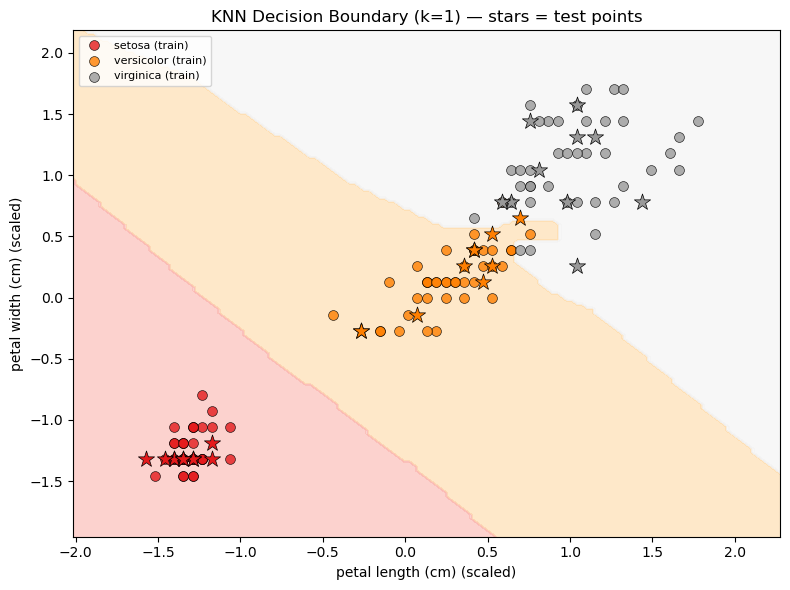

In [21]:
# ── 5.6  Decision Boundary Visualisation (2 Features) ────────────────────────

# Use only 2 features for 2D visualisation
feat_idx = [2, 3]   # petal length, petal width (most separable)
feat_names = [iris.feature_names[i] for i in feat_idx]

X2_train = X_train_sc[:, feat_idx]
X2_test  = X_test_sc[:, feat_idx]

knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(X2_train, y_train)

# Create mesh
h = 0.03
x_min, x_max = X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5
y_min, y_max = X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = plt.cm.get_cmap('Pastel1', 3)
cmap_pt = plt.cm.get_cmap('Set1', 3)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)

for cls, name in enumerate(iris.target_names):
    idx_tr = y_train == cls
    idx_te = y_test == cls
    ax.scatter(X2_train[idx_tr, 0], X2_train[idx_tr, 1],
               c=[cmap_pt(cls)], label=f'{name} (train)', s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax.scatter(X2_test[idx_te, 0], X2_test[idx_te, 1],
               c=[cmap_pt(cls)], marker='*', s=150, alpha=1.0, edgecolors='k', linewidths=0.5)

ax.set_xlabel(f'{feat_names[0]} (scaled)')
ax.set_ylabel(f'{feat_names[1]} (scaled)')
ax.set_title(f'KNN Decision Boundary (k={best_k}) — stars = test points')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
# ── 5.7  Save & Reload the Model ─────────────────────────────────────────────

# Save both scaler and model (always save together!)
joblib.dump(scaler, 'scaler_iris.pkl')
joblib.dump(knn,    'knn_iris.pkl')
print("✅ Model saved: knn_iris.pkl")
print("✅ Scaler saved: scaler_iris.pkl")

# Reload and verify
scaler_loaded = joblib.load('scaler_iris.pkl')
knn_loaded    = joblib.load('knn_iris.pkl')

y_pred_reload = knn_loaded.predict(scaler_loaded.transform(X_test))
print(f"\nReloaded model accuracy: {accuracy_score(y_test, y_pred_reload):.2%} ✓")

✅ Model saved: knn_iris.pkl
✅ Scaler saved: scaler_iris.pkl

Reloaded model accuracy: 93.33% ✓


In [23]:
# ── 5.8  Predict on New Samples ───────────────────────────────────────────────

new_samples = pd.DataFrame({
    'sepal length (cm)': [5.1, 6.3, 7.2],
    'sepal width (cm)' : [3.5, 2.8, 3.0],
    'petal length (cm)': [1.4, 4.9, 5.8],
    'petal width (cm)' : [0.2, 1.5, 1.8],
})

new_scaled = scaler_loaded.transform(new_samples)
predictions = knn_loaded.predict(new_scaled)
probabilities = knn_loaded.predict_proba(new_scaled)

print("Predictions for new samples:")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    species = iris.target_names[pred]
    confidence = prob.max()
    print(f"  Sample {i+1}: {species:12s}  (confidence: {confidence:.0%})")

Predictions for new samples:
  Sample 1: setosa        (confidence: 100%)
  Sample 2: virginica     (confidence: 60%)
  Sample 3: virginica     (confidence: 100%)
